In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("..")

import importlib
import src.preprocessing.pipeline as pl
importlib.reload(pl)

build_preprocessing_pipeline = pl.build_preprocessing_pipeline
get_feature_lists = pl.get_feature_lists

set_config(transform_output="pandas")

DATA_PATH = "../data/processed/health_index_ae_dataset.csv"
MODEL_PATH = "../models/health_index_ae_regressor.joblib"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(24042, 24)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,...,temp_gap,vibration_rpm_interaction,pressure_current_interaction,vibration_delta,temperature_delta,anomaly_trend_raw,reconstruction_error,reconstruction_error_norm,health_index_ae,health_status
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,...,35.61,697.329,120.360,0.00,0.00,0.000,0.000004,0.004974,0.995026,good
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,...,30.38,674.700,125.080,-0.06,-8.93,0.000,0.000004,0.004555,0.995445,good
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,...,36.10,612.517,NaN,-0.04,9.12,3.648,0.000003,0.003181,0.996819,good
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,...,29.64,661.504,108.254,0.05,-6.66,0.030,0.000003,0.003954,0.996046,good
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,...,30.59,776.072,98.568,0.12,-1.65,0.072,0.000003,0.003573,0.996427,good


In [3]:
target = "health_index_ae"

numeric_features, categorical_features = get_feature_lists()
all_features = numeric_features + categorical_features

forbidden_cols = [
    "health_index_ae",
    "health_status",
    "reconstruction_error",
    "reconstruction_error_norm",
    "failure_within_24h",
]

features = [col for col in all_features if col in df.columns and col not in forbidden_cols]

X = df[features]
y = df[target]

print("Features utilisées :", len(features))

Features utilisées : 15


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = joblib.load(MODEL_PATH)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['vibration_rms',
                                                   'temperature_motor',
                                                   'current_phase_avg',
                                                   'pressure_level', 'rpm',
                                                   'hours_since_maintenance',
                                                   'ambient_temp', 'temp_gap',
                                                   'vibration_rpm_interaction',
                                        

In [6]:
y_pred = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.0089
RMSE : 0.0493
R2   : 0.8559


In [8]:
df_eval = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred
})

df_eval["abs_error"] = np.abs(df_eval["y_true"] - df_eval["y_pred"])
df_eval["residual"] = df_eval["y_true"] - df_eval["y_pred"]

df_eval.head()

,y_true,y_pred,abs_error,residual
0,0.135145,0.535996,0.400850,-0.400850
1,0.990574,0.991061,0.000487,-0.000487
2,0.990879,0.918227,0.072652,0.072652
3,0.985429,0.985838,0.000408,-0.000408
4,0.983618,0.983890,0.000272,-0.000272


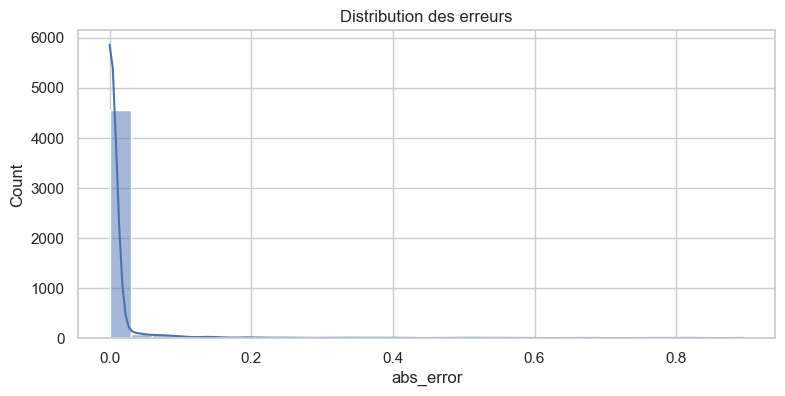

In [9]:
sns.histplot(df_eval["abs_error"], bins=30, kde=True)
plt.title("Distribution des erreurs")
plt.show()

In [10]:
df_eval["zone"] = pd.cut(
    df_eval["y_true"],
    bins=[0, 0.5, 0.8, 1],
    labels=["critical", "warning", "good"]
)

zone_error = df_eval.groupby("zone")["abs_error"].mean().reset_index()

zone_error

,zone,abs_error
0,critical,0.187185
1,warning,0.095616
2,good,0.004288


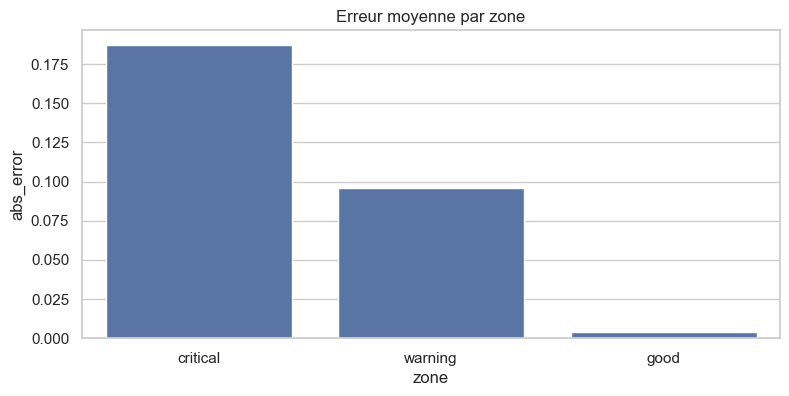

In [11]:
sns.barplot(data=zone_error, x="zone", y="abs_error")
plt.title("Erreur moyenne par zone")
plt.show()

In [12]:
rf = model.named_steps["model"]
preprocessor = model.named_steps["preprocessor"]

In [13]:
X_train_transformed = preprocessor.transform(X_train)

In [14]:
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": X_train_transformed.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
4,num__rpm,0.305039
8,num__vibration_rpm_interaction,0.184628
0,num__vibration_rms,0.152525
1,num__temperature_motor,0.147792
3,num__pressure_level,0.056386
9,num__pressure_current_interaction,0.035705
10,num__vibration_delta,0.027959
7,num__temp_gap,0.019545
2,num__current_phase_avg,0.015726
5,num__hours_since_maintenance,0.012947


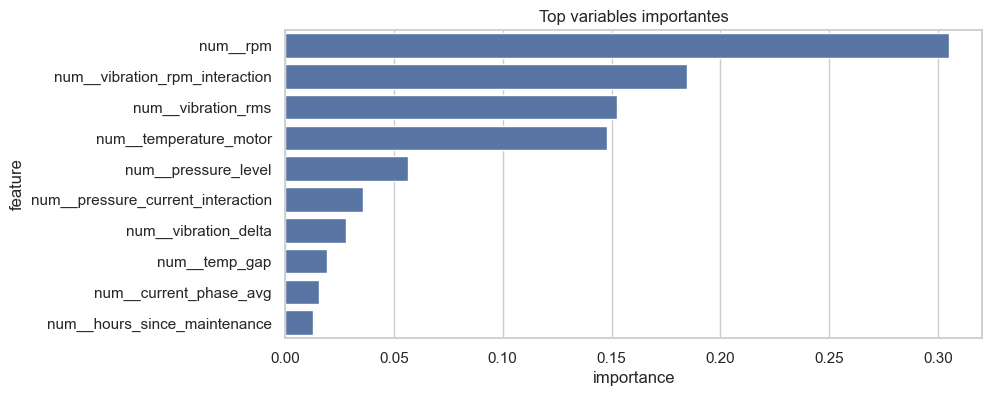

In [15]:
top_features = importance_df.head(10)

sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top variables importantes")
plt.show()

In [16]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

In [17]:
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

perm_df.head(10)

,feature,importance
4,rpm,0.133511
1,temperature_motor,0.131877
0,vibration_rms,0.128720
8,vibration_rpm_interaction,0.065152
3,pressure_level,0.040608
14,operating_mode,0.022822
9,pressure_current_interaction,0.018751
2,current_phase_avg,0.010438
7,temp_gap,0.003827
13,machine_type,0.002276


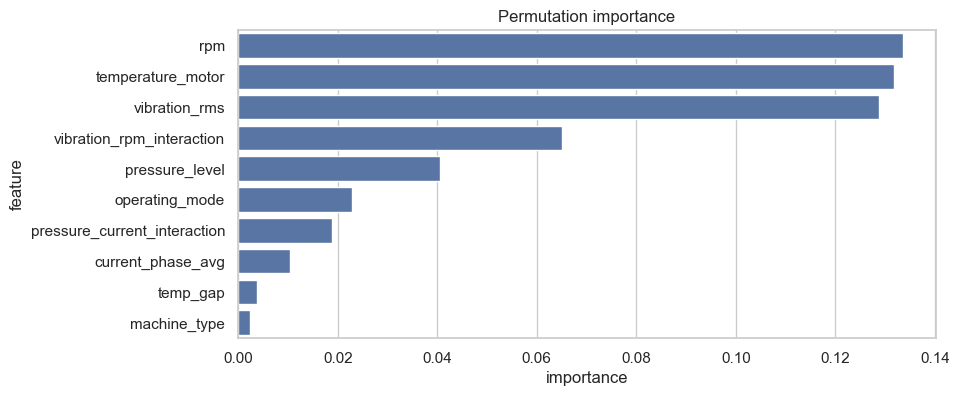

In [18]:
sns.barplot(data=perm_df.head(10), x="importance", y="feature")
plt.title("Permutation importance")
plt.show()

In [19]:
df_eval[df_eval["zone"] == "critical"].sort_values("abs_error", ascending=False).head(10)

,y_true,y_pred,abs_error,residual,zone
3816,0.051050,0.874532,0.823482,-0.823482,critical
3788,0.006141,0.534111,0.527970,-0.527970,critical
2397,0.390247,0.901271,0.511024,-0.511024,critical
2457,0.417125,0.878069,0.460944,-0.460944,critical
0,0.135145,0.535996,0.400850,-0.400850,critical
2904,0.405452,0.792537,0.387085,-0.387085,critical
1066,0.052230,0.425540,0.373310,-0.373310,critical
1304,0.494478,0.847413,0.352935,-0.352935,critical
2057,0.329000,0.675075,0.346075,-0.346075,critical
1123,0.054520,0.392164,0.337644,-0.337644,critical


In [20]:
df_eval[df_eval["zone"] == "good"].sort_values("abs_error", ascending=False).head(10)

,y_true,y_pred,abs_error,residual,zone
1216,0.911507,0.151839,0.759668,0.759668,good
4094,0.813125,0.208023,0.605102,0.605102,good
2405,0.953134,0.552231,0.400903,0.400903,good
1830,0.935639,0.540168,0.395471,0.395471,good
4438,0.997908,0.615506,0.382402,0.382402,good
3252,0.876852,0.507885,0.368967,0.368967,good
743,0.896303,0.561447,0.334857,0.334857,good
4460,0.881875,0.554183,0.327692,0.327692,good
1628,0.968328,0.644759,0.323569,0.323569,good
644,0.959150,0.671464,0.287686,0.287686,good
